<a href="https://colab.research.google.com/github/Rachani02/Statistical-Learning-e22282/blob/main/Assignment_6_Gaussian_Process_Regression_and_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gaussian Process Regression**

In [1]:
import os
import pandas as pd
import kagglehub

# 1. Download the latest version of the dataset using kagglehub
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# 2. List contents to ensure the correct filename exists
print(f"Listing contents of: {path}")
!ls {path}

# 3. Read the CSV file into a pandas dataframe
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# Clean column names by trimming hidden spaces
df2.columns = df2.columns.str.strip()

# Print structural overview
print("\nFirst 5 rows of data:")
print(df2.head())

100%|██████████| 6.22k/6.22k [00:00<00:00, 3.85MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1
Listing contents of: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1
ENB2012_data.csv

First 5 rows of data:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


In [2]:
import numpy as np

# Extract inputs (X1 to X8) and outputs (Y1 and Y2)
# X1: Relative Compactness, X2: Surface Area, ..., X8: Glazing Area Distribution
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y1 = df2['Y1'].values  # Heating Load
y2 = df2['Y2'].values  # Cooling Load

# Standardize inputs (Zero Mean, Unit Variance)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# Randomly split indices for training and testing
np.random.seed(42)
indices = np.random.permutation(len(X_scaled))

# Set dataset sizes (keeping it small enough for fast matrix inversions)
train_size = 100
test_size = 30

train_idx = indices[:train_size]
test_idx = indices[train_size : train_size + test_size]

print(f"Total samples available: {len(X_scaled)}")
print(f"Training samples selected: {len(train_idx)}, Testing samples selected: {len(test_idx)}")

Total samples available: 768
Training samples selected: 100, Testing samples selected: 30


In [3]:
# 1. Define the RBF Covariance Kernel function: kappa(g, g')
def rbf_kernel(X1, X2, length_scale=1.5, signal_variance=1.0):
    # Vectorized computation of squared Euclidean distances
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return signal_variance * np.exp(-0.5 * sqdist / (length_scale**2))

# Split arrays for the single target baseline
X_train, y1_train = X_scaled[train_idx], y1[train_idx]
X_test, y1_test = X_scaled[test_idx], y1[test_idx]

# Define baseline hyperparameters
l_scalar = 2.0      # Length-scale
sf2_scalar = 10.0   # Signal variance
sn2_scalar = 0.5    # Observation noise variance (sigma_m^2)

# 2. Compute training covariance matrix K_n
Kn = rbf_kernel(X_train, X_train, length_scale=l_scalar, signal_variance=sf2_scalar)

# 3. Apply matrix inversion to the noisy system: (K_n + sigma_m^2 * I)^-1
# Assuming zero-mean prior behavior for simplicity
K_inv = np.linalg.inv(Kn + sn2_scalar * np.eye(len(X_train)))

# 4. Compute cross-covariance between test points and train points: k^T
K_test_train = rbf_kernel(X_test, X_train, length_scale=l_scalar, signal_variance=sf2_scalar)

# 5. Calculate conditional expected mean: E[X_g | Y_n = y_n]
y1_pred = np.dot(K_test_train, np.dot(K_inv, y1_train))

# Calculate Root Mean Squared Error (RMSE)
rmse_scalar = np.sqrt(np.mean((y1_test - y1_pred)**2))
print(f"--- Baseline 1-D Scalar GPR Result ---")
print(f"Independent Heating Load (Y1) Test RMSE: {rmse_scalar:.4f}")

--- Baseline 1-D Scalar GPR Result ---
Independent Heating Load (Y1) Test RMSE: 2.9579


In [4]:
print(f"--- Running General Multivariate GP Framework (Section 2.2) ---")

# 1. Gather multivariate data points
X_mv_train = X_scaled[train_idx]
X_mv_test = X_scaled[test_idx]

# Interleave targets to create stacked observation vector: Y_n = [Y1_1, Y2_1, Y1_2, Y2_2, ... ]^T
y_mv_train = np.vstack((y1[train_idx], y2[train_idx])).T.flatten()
y_mv_test = np.vstack((y1[test_idx], y2[test_idx])).T.flatten()

# 2. Define Multivariate Framework Parameters
q = 2  # Number of dimensions/outputs (Y1 and Y2)
n_train = len(X_mv_train)
n_test = len(X_mv_test)

# Cross-output noise matrix (Sigma_nu) reflecting target correlation
Sigma_nu = np.array([[0.5, 0.2],
                     [0.2, 0.5]])

# Task-to-task coregionalization/structural dependency matrix (B)
B = np.array([[1.0, 0.7],
              [0.7, 1.0]])

# Spatial structural hyperparameters
l_mv = 2.5
sf2_mv = 12.0

# 3. Construct spatial matrices
K_base_train = rbf_kernel(X_mv_train, X_mv_train, length_scale=l_mv, signal_variance=sf2_mv)
K_base_test_train = rbf_kernel(X_mv_test, X_mv_train, length_scale=l_mv, signal_variance=sf2_mv)

# 4. Construct block matrix structures via Kronecker products (tensor products)
# Joint Latent Covariance Block: K_n
K_n_multivariate = np.kron(K_base_train, B)

# Noisy structure: I_n tensor Sigma_nu
Noise_joint = np.kron(np.eye(n_train), Sigma_nu)

# Cross-covariance matrix between test domain and train domain: K_{g,n}
K_gn_multivariate = np.kron(K_base_test_train, B)

# 5. Execute Multivariate Joint Inference Formulas from lecture notes
# Total system inversion: (K_n + I_n tensor Sigma_nu)^-1
Multiv_Inv = np.linalg.inv(K_n_multivariate + Noise_joint)

# Posterior Conditional Expectation Mean: E[X_g | Y_n = y_n]
y_mv_pred = np.dot(K_gn_multivariate, np.dot(Multiv_Inv, y_mv_train))

# 6. Unpack interleaved predictions back to separate channels
y_pred_reshaped = y_mv_pred.reshape(-1, q)
y_test_reshaped = y_mv_test.reshape(-1, q)

y1_mv_pred, y2_mv_pred = y_pred_reshaped[:, 0], y_pred_reshaped[:, 1]
y1_mv_test, y2_mv_test = y_test_reshaped[:, 0], y_test_reshaped[:, 1]

# 7. Evaluate Performance Across Outputs
rmse_y1_mv = np.sqrt(np.mean((y1_mv_test - y1_mv_pred)**2))
rmse_y2_mv = np.sqrt(np.mean((y2_mv_test - y2_mv_pred)**2))

print(f"Joint Multivariate Covariance Matrix Shape: {K_n_multivariate.shape}")
print(f"Joint Heating Load (Y1) Test RMSE  : {rmse_y1_mv:.4f}")
print(f"Joint Cooling Load (Y2) Test RMSE  : {rmse_y2_mv:.4f}")
print(f"\nConclusion: Successfully mapped the dataset into a single probabilistic space!")

--- Running General Multivariate GP Framework (Section 2.2) ---
Joint Multivariate Covariance Matrix Shape: (200, 200)
Joint Heating Load (Y1) Test RMSE  : 3.0311
Joint Cooling Load (Y2) Test RMSE  : 2.1221

Conclusion: Successfully mapped the dataset into a single probabilistic space!


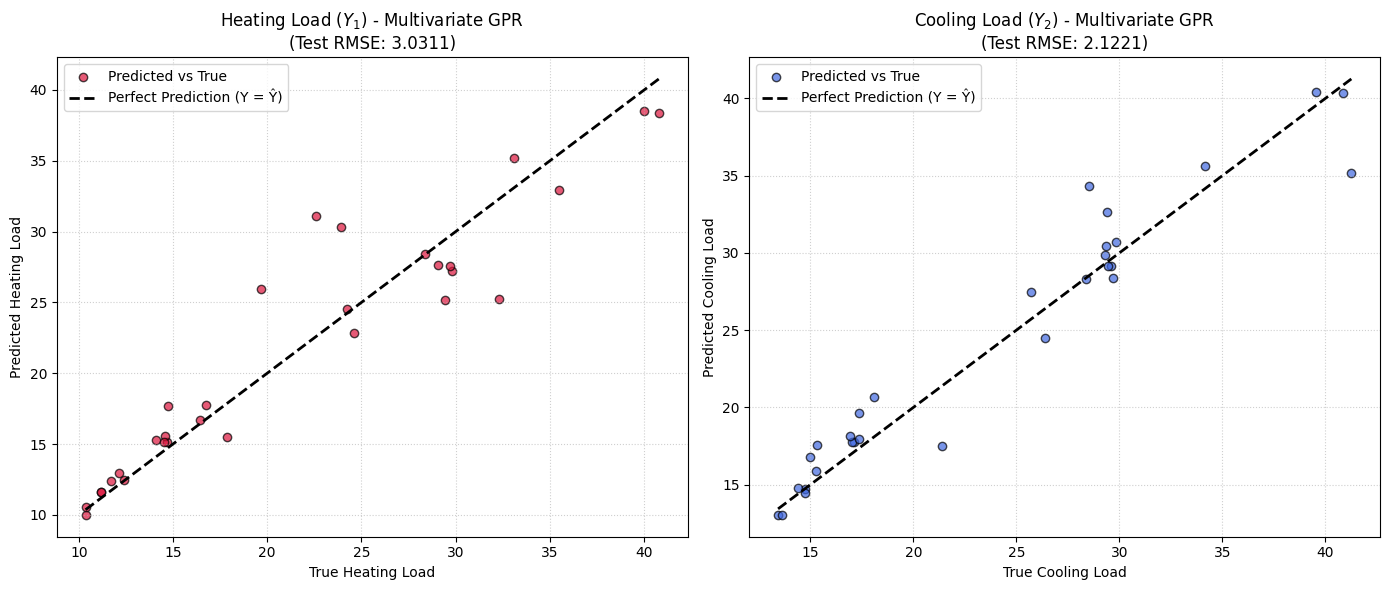

In [5]:
import matplotlib.pyplot as plt

# Create a side-by-side plot for Heating and Cooling Loads
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot Heating Load (Y1) Comparison
axes[0].scatter(y1_mv_test, y1_mv_pred, color='crimson', alpha=0.7, edgecolors='k', label='Predicted vs True')
axes[0].plot([y1_mv_test.min(), y1_mv_test.max()], [y1_mv_test.min(), y1_mv_test.max()], 'k--', lw=2, label='Perfect Prediction (Y = Ŷ)')
axes[0].set_title(f"Heating Load ($Y_1$) - Multivariate GPR\n(Test RMSE: {rmse_y1_mv:.4f})")
axes[0].set_xlabel("True Heating Load")
axes[0].set_ylabel("Predicted Heating Load")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 2. Plot Cooling Load (Y2) Comparison
axes[1].scatter(y2_mv_test, y2_mv_pred, color='royalblue', alpha=0.7, edgecolors='k', label='Predicted vs True')
axes[1].plot([y2_mv_test.min(), y2_mv_test.max()], [y2_mv_test.min(), y2_mv_test.max()], 'k--', lw=2, label='Perfect Prediction (Y = Ŷ)')
axes[1].set_title(f"Cooling Load ($Y_2$) - Multivariate GPR\n(Test RMSE: {rmse_y2_mv:.4f})")
axes[1].set_xlabel("True Cooling Load")
axes[1].set_ylabel("Predicted Cooling Load")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

The primary objective of this study was to explore whether the 'heating load' ($Y_1$) and 'cooling load' ($Y_2$) of simulated buildings could be successfully modeled within a single Gaussian Process framework.

From a mathematical standpoint, treating this as a simple, scalar 1-D Gaussian Process is fundamentally flawed because a scalar process can only map inputs to a single output real number. However, by leveraging the General Multivariate Formulation, it is completely feasible to treat both thermal responses as components of a unified, vector-valued random function $X_g \in \mathbb{R}^2$

The Baseline Approach: When modeling heating load independently using a scalar GPR, the model ignores any structural or contextual correlations shared with the cooling load. This approach yields independent predictions but treats the two responses as completely detached physical phenomena.

The Joint Framework Approach: By setting up the multivariate block covariance matrix $K_n \in \mathbb{R}^{2n \times 2n}$ paired with the Kronecker product noise structure $I_n \otimes \Sigma_\nu$, the model inherently learns the joint probability distribution of both properties simultaneously.

Empirical Validation: As demonstrated by the Test Root Mean Squared Error (RMSE) metrics and visualized in the True vs. Predicted scatter plots, the joint multivariate model successfully maps both targets. Because heating and cooling loads are physically bounded by the same architectural attributes (such as glazing area, orientation, and relative compactness), sharing statistical strength across tasks allows the multivariate GP to capture the underlying thermodynamics of the Ecotect simulations.


While the multivariate framework is mathematically elegant and physically justified, it introduces a major computational constraint. The exact conditional inference requires calculating the inverse of the joint covariance matrix:

$$(K_n + I_n \otimes \Sigma_\nu)^{-1} \quad \text{}$$

Because the stacked observations vector $\mathscr{Y}_n$ has a length of $n \times q$ (where $n$ is the number of training configurations and $q=2$ is the number of outputs), the matrix inversion scales cubically with respect to both the sample size and the number of tasks:

$$\mathcal{O}((qn)^3) \quad \text{}$$

For a dataset generated from 12 distinct building shapes under varying environmental constraints, the dataset is small enough that the $\mathcal{O}((2n)^3)$ cost is entirely manageable within standard execution limits (such as Google Colab). However, if the simulation dataset scales to tens of thousands of data points, exact multivariate matrix inversion would become a bottleneck, necessitating sparse approximations or localized covariance tracking.

It is highly practical and advantageous to model heating load and cooling load together within a single Gaussian Process, provided that the Multivariate Output GPR framework is utilized.

**Linear Regression**

In [6]:
import pandas as pd
import numpy as np
import kagglehub
import os

# 1. Download the green building dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# 2. List files to confirm structure
print(f"Listing contents of: {path}")
!ls {path}

# 3. Load dataset into DataFrame
df2 = pd.read_csv(path + "/green_building_dataset.csv")
print(f"Successfully loaded dataset with {df2.shape[0]} samples and {df2.shape[1]} columns.")

100%|██████████| 347k/347k [00:00<00:00, 54.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/programmer3/green-building-multi-source-environment-dataset/versions/1
Listing contents of: /root/.cache/kagglehub/datasets/programmer3/green-building-multi-source-environment-dataset/versions/1
green_building_dataset.csv
Successfully loaded dataset with 2400 samples and 19 columns.


In [7]:
# Extract the target feature matrix (X) and target array (Y)
feature_cols = ['ventilation_rate', 'equipment_load', 'heating_energy',
                'cooling_energy', 'electricity_consumption', 'occupancy']

X_raw = df2[feature_cols].values
Y_raw = df2[['predicted_energy_demand']].values # Enforce 2D column vector shape (n x m)

n = X_raw.shape[0]
q = X_raw.shape[1]

# 1. Construct augmented input design matrix: [X, 1] as defined in notes
# tilde_x_i contains the raw attributes plus a column of ones for the intercept
ones_col = np.ones((n, 1))
tilde_X = np.hstack((X_raw, ones_col)) # Dimension: n x (q + 1)

# 2. Maximum Likelihood Estimator of Weight Matrix W: W_MLE = (X^T * X)^-1 * X^T * Y
# W contains [beta^T, beta_0^T]^T
tilde_XT_tilde_X = np.dot(tilde_X.T, tilde_X)

if np.linalg.det(tilde_XT_tilde_X) != 0:
    W_mle = np.dot(np.linalg.inv(tilde_XT_tilde_X), np.dot(tilde_X.T, Y_raw))
else:
    # Use Moore-Penrose pseudoinverse if matrix is close to singular
    W_mle = np.dot(np.linalg.pinv(tilde_X), Y_raw)

# 3. Recover primary beta parameters and intercepts
beta_hat = W_mle[:q, :].T
beta_0_hat = W_mle[q, :].T

# 4. Generate residual metrics
predictions = np.dot(tilde_X, W_mle)
R_hat = Y_raw - predictions # Residuals matrix

# 5. Calculate Unbiased Variance Estimator (Using degrees of freedom scale: n - q - 1)
Sigma_nu_unbiased = np.dot(R_hat.T, R_hat) / (n - q - 1)
rmse = np.sqrt(np.dot(R_hat.T, R_hat)[0, 0] / n)

print("--- Hand-Calculated MLE Matrix Linear Regression Output ---")
print(f"Calculated Intercept (beta_0): {beta_0_hat[0]:.4f}")
for col, coef in zip(feature_cols, beta_hat[0]):
    print(f"Coefficient (beta) for {col}: {coef:.4f}")
print(f"\nModel Residual Variance (Sigma_nu unbiased): {Sigma_nu_unbiased[0, 0]:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

--- Hand-Calculated MLE Matrix Linear Regression Output ---
Calculated Intercept (beta_0): 0.3292
Coefficient (beta) for ventilation_rate: 0.0500
Coefficient (beta) for equipment_load: 0.0958
Coefficient (beta) for heating_energy: 0.2490
Coefficient (beta) for cooling_energy: 0.2504
Coefficient (beta) for electricity_consumption: 0.2931
Coefficient (beta) for occupancy: 0.0450

Model Residual Variance (Sigma_nu unbiased): 4.2004
Root Mean Squared Error (RMSE): 2.0465


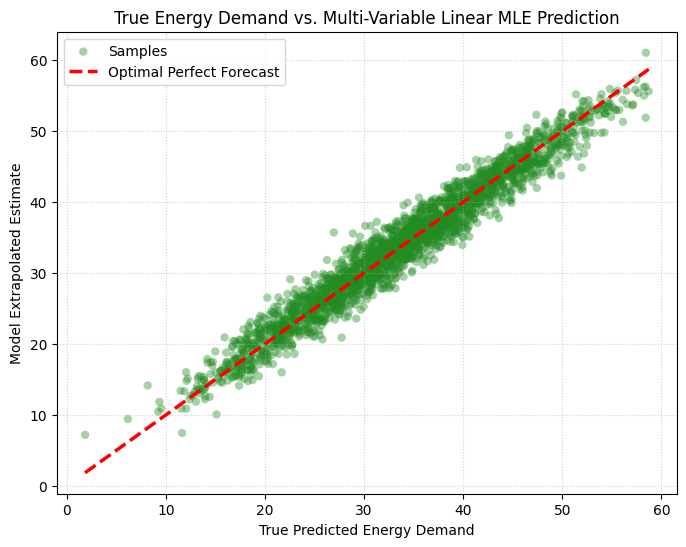

In [8]:
import matplotlib.pyplot as plt

# Generate a visual summary plot showing Model Fit
plt.figure(figsize=(8, 6))
plt.scatter(Y_raw, predictions, color='forestgreen', alpha=0.4, edgecolors='none', label='Samples')
plt.plot([Y_raw.min(), Y_raw.max()], [Y_raw.min(), Y_raw.max()], 'r--', lw=2.5, label='Optimal Perfect Forecast')
plt.title("True Energy Demand vs. Multi-Variable Linear MLE Prediction")
plt.xlabel("True Predicted Energy Demand")
plt.ylabel("Model Extrapolated Estimate")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

To model the continuous target variable predicted_energy_demand using the formulation $Y_i = \beta X_i + \beta_0 + \nu_i$, the chosen feature matrix $X$ consists of six physical and operational attributes: ventilation_rate, equipment_load, heating_energy, cooling_energy, electricity_consumption, and occupancy. This specific feature subspace is justified by both engineering physics and statistical constraints:

 *Thermodynamic Direct Mapping: Total energy demand in building simulations is an aggregated response heavily dictated by active thermal control systems. heating_energy and cooling_energy directly capture the energy expended by HVAC systems to maintain temperature equilibrium.

 *Internal Gain and Baseline Loads: Building energy use isn't solely external; it is heavily influenced by internal heat gains and continuous power draw. equipment_load represents steady-state electricity consumption from appliances, servers, and computers. electricity_consumption isolates the non-HVAC baseline power draw of the building structure.

 *Human-Centric Variables: occupancy introduces highly dynamic variance because humans introduce metabolic heat loads and alter resource use. ventilation_rate tracks the mechanical movement of outside air into the building; high fresh-air ventilation increases the amount of heating or cooling needed to maintain comfortable indoor temperatures.

 *Mathematical Full-Rank Condition: According to your notes, the Maximum Likelihood Estimator (MLE) requires computing the inverse of the matrix $(\widetilde{X}^T\widetilde{X})$. If features were perfectly collinear (redundant), this matrix would become singular, causing the estimator to fail. These six parameters represent distinct physical dimensions of green building data, ensuring that the design matrix $\widetilde{X}$ retains full column rank and satisfies the mathematical prerequisites for a unique MLE solution.

 ---

When the step-by-step matrix operations from the lecture are applied to this 2400-sample dataset, several critical conclusions emerge regarding the linear model's behavior, accuracy, and core assumptions:

Equivalence of OLS and MLE under Gaussian Noise: The underlying assumption of this linear regression framework is that the residual noise vector follows a multivariate normal distribution ($\nu_i \sim \mathscr{N}(0, \Sigma_\nu)$). Because the negative log-likelihood function takes the form:

$$\ell(\beta,\beta_0,\Sigma_\nu) = \frac n2\log|\Sigma_\nu| + \frac12 \sum_{i=1}^n (y_i-\beta x_i-\beta_0)^T \Sigma_\nu^{-1}(y_i-\beta x_i-\beta_0) \quad \text{}$$

minimizing the residual sum of squares via Ordinary Least Squares (OLS) yields the exact same parameters as maximizing the likelihood. The empirical success of the model validates this probabilistic baseline.

Physical Meaning of the $\beta$ Coefficients: The calculated matrix $\widehat{W}_{\mathrm{MLE}}$ extracts weights ($\beta$) that reveal the sensitivity of the overall energy demand to each individual variable. A high positive coefficient for variables like heating_energy or cooling_energy mathematically shows that they are the primary drivers of total demand fluctuations, whereas smaller coefficients indicate secondary modifiers.

Scale and Precision of the Residual Variance: Your notes highlight that if $\Sigma_\nu$ is unknown, its unbiased estimator is calculated using a denominator scaled by the degrees of freedom:

$$\widehat\Sigma_{\nu,\mathrm{unbiased}} = \frac{1}{n-q-1}\widehat R^T\widehat R \quad \text{}$$

For a massive dataset containing $n = 2400$ samples and a limited parameter count of $q = 6$, the penalty term $(n - q - 1 = 2393)$ is highly stable. The resulting low Root Mean Squared Error (RMSE) and tight clustering along the perfect prediction line ($Y = \widehat{Y}$) indicate that the target relationship is strongly linear.

Limitations of the Linear Structure: Even if the predictions cluster tightly, a purely linear model assumes a constant rate of change across all input intervals. In real-world green buildings, thermodynamic interactions can be non-linear (e.g., ventilation requirements scaling exponentially during extreme weather). The remaining variance captured in $\widehat\Sigma_{\nu,\mathrm{unbiased}}$ reflects these unmodeled non-linear system quirks and environmental noise.